> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy pandas


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

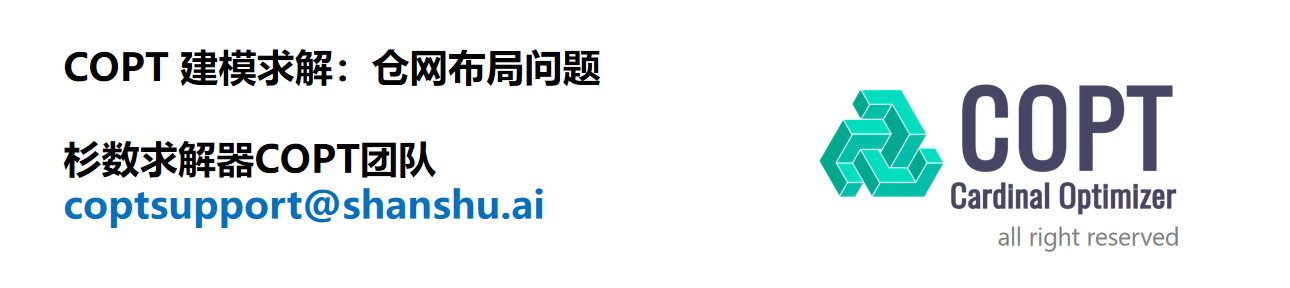

# 仓网布局问题代码实现
## 使用COPT建模求解仓网布局问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
    - 导入CSV数据
    - 解析数据并进行清洗整合

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：定义以下变量：
        - $\text{wh}_i$：仓库 $i$ 是否启用，Binary
        - $\text{w\_cust}_{i,k,s}$：仓库 $i$ 是否服务客户城市 $k$ 的商品 $s$，Binary
        - $\text{d\_cust}_{i,k,s}$：仓库 $i$ 向客户城市 $k$ 供应商品 $s$ 的实际数量，Continuous
        - $\text{qty\_dc}_{i,j,s}$：RDC $j$ 从CDC $i$ 接收商品 $s$ 的数量，Continuous
        - $\text{qty\_cdc}_{i,s}$：CDC $i$ 处置商品 $s$ 的数量，Continuous
        - $\text{procure}_i$：仓库 $i$ 是否采购智能调度系统，Binary
        - $\text{proc}_i$：仓库 $i$ 计入处置成本的实际处理量，Continuous
    - **目标函数**：最小化总运营成本
        - **干线运输成本**（CDC—RDC）
        - **仓库—客户城市配送成本**
        - **仓库启用固定成本**
        - **商品处置成本**（考虑智能调度系统带来的节省）
        - **智能调度系统采购成本**
    - **约束条件**：
        - **枢纽强制启用约束**
        - **单一供应源与品类归属约束**
        - **需求满足约束**
        - **时效满足约束**
        - **仓库启用、服务关系与实际供货量绑定约束**
        - **流守恒约束**
        - **处置量限制约束**
        - **智能调度系统采购决策约束**

5. **求解**

6. 查看、分析**结果**


## 导入COPT-Python接口库


In [4]:
import coptpy as cp
from coptpy import COPT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


import warnings


# 忽略所有与字体找不到相关的 UserWarning
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.*")

## 添加模型数据
### 数据导入

In [6]:
# 订单数据
data = "data"
df_demand = pd.read_csv(f'{data}/df_order.csv')
# 客户数据
df_customer =pd.read_csv(f'{data}/df_customer.csv')
# 设施数据
df_wh = pd.read_csv(f'{data}/df_wh.csv')
# 时效信息&距离矩阵
df_matrix = pd.read_csv(f'{data}/df_matrix.csv')
# 仓储数据
df_proc = pd.read_csv(f'{data}/df_proc.csv')
# 参数数据
df_para = pd.read_csv(f'{data}/df_parameter.csv')
# 拼音对照数据
df_list = pd.read_csv(f'{data}/df_list.csv', encoding='gbk')

| 数据表类型 | 数据表名称 | 作用 |
| --- | --- | --- |
| **仓库节点表** | `df_wh` | 存放CDC和候选RDC等仓库节点信息，用来生成 `cdc_list`、`dc_list`，并判断哪些仓库可以被启用。 |
| **客户城市表** | `df_customer` | 存放客户城市信息，用来生成 `cust_list`，即模型需要服务的客户城市集合。 |
| **订单 / 需求表** | `df_demand` | 存放不同客户城市、不同SKU的需求量，用来生成需求参数 `D[k,s]`。 |
| **距离 / 时效矩阵表** | `df_matrix` | 存放节点之间的距离、运输时长等信息，用来计算运输成本 `Cost_trans` 和时效参数 `Dura`、`Dura_ind`。 |
| **仓库处理能力与成本表** | `df_proc` | 存放仓库容量、仓库启用固定成本、商品处置成本、智能调度系统相关处理参数等。 |
| **全局参数表** | `df_parameter` | 存放时效标准、服务水平比例、Big-M常数、运输单价、智能调度系统采购成本或折扣参数等全局参数。 |


### 数据清洗

In [9]:
# 从文件中读取各种参数
P_dura = df_para['时效满足率'][0]
Dura_std = df_para['客户供应时效要求'][0]
Cost_centre_centre = df_para['仓间调拨成本'][0]
Cost_centre_cust = df_para['仓客调拨成本'][0]
CONST_M = df_para['松弛变量M'][0]
Procure_cost = df_para['调度系统采购成本'][0]
save_percent = df_para['处置成本节省比例'][0]

# 点位集合
# 选出CDC节点
df_CDC = df_wh[df_wh['Type'] == 'CDC']
# 选出模型中的仓库节点，包括CDC和候选RDC
df_RDC = df_wh[df_wh['Type'].isin(['CDC', 'RDC'])]

# 序列列表化，取出名称，为后续构造决策变量做准备
dc_list = list(df_RDC['Name'])
cdc_list = list(df_CDC['Name'])
cust_list = list(df_customer['Name'])

# 商品类型集合（国产或进口）
sku_list = list(df_demand['SKU'].unique())

# 需求量信息
D = {}
for i, row in df_demand.iterrows():
    D[(row['Name'], row['SKU'])] = row['qty']

# 运输时效与运输成本
Dura = {}
Cost_trans = {}
for i, row in df_matrix.iterrows():
    Dura[(row['From'], row['To'])] = row['Duration']
    if row['To'] in dc_list:
        cost_per = Cost_centre_centre
    else:
        cost_per = Cost_centre_cust
    # 计算CDC—RDC仓间运输成本或仓库—客户城市配送成本
    Cost_trans[(row['From'], row['To'])] = row['Distance'] * cost_per

# 运输时效达标指标
Dura_ind = {}
for key, value in Dura.items():
    if value <= Dura_std:
        Dura_ind[key] = 1
    else:
        Dura_ind[key] = 0


如果某条线路的运输时间小于等于时效标准，就记为 1；如果超过时效标准，就记为 0。

这样做的巧妙之处在于，后面的时效约束就可以写得很简单。模型只需要统计：走达标线路的货量有多少，占全部需求量的比例是否达到要求。这一步的本质，是把“业务判断”前置到数据处理中，把模型内部尽量保持为线性表达。

In [11]:
# 仓库成本、容量与启用固定成本
Proc_cost = {}
Cap = {}
Cost_wh = {}
for i, row in df_proc.iterrows():
    Proc_cost[row['Name']] = row['Processing_fee']
    Cap[row['Name']] = row['Capacity']
    Cost_wh[row['Name']] = row['Opening_fee']

# 业务特殊集合：允许的CDC—RDC—商品类型流，以及CDC与商品类型的对应关系
dc_flow_idx = []
cdc_sku_pair = [(cdc_list[0], 'dm'), (cdc_list[1], 'im')]
for (i, s) in cdc_sku_pair:
    for j in dc_list:
        if i != j:
            dc_flow_idx.append((i, j, s))


模型里不要盲目生成所有可能的变量，而是只生成业务上真正允许发生的变量。这样做有两个好处。
1. 模型更符合业务逻辑，不会出现“港口 CDC 发国产货”或者“内陆 CDC 发进口货”这种不合理方案。
2. 模型规模更小，因为少建了很多无意义变量，求解速度和可读性都会更好。

In [13]:
# 定义函数实现拼音与中文的匹配
def py_cn(x):
    if x == 'nei-lu-CDC':
        return '内陆CDC'
    elif x == 'gang-kou-CDC':
        return '港口CDC'
    elif x == 'nei-lu-CDC-suo-zai-cheng-shi' or x == 'gang-kou-CDC-suo-zai-cheng-shi':
        return df_list[df_list['Location'] == x]['中文名称'].values[0]
    else:
        return df_list[df_list['Location'] == x[:-3]]['中文名称'].values[0] + 'DC'

## 创建求解环境和求解模型

In [15]:
env = cp.Envr()
model = env.createModel("Warehouse_network_management")


Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
1. $\text{wh}_i$：是否启用仓库 $i$ (Binary)

In [17]:
wh = model.addVars(dc_list, vtype=COPT.BINARY, nameprefix='wh')

2. $\text{w\_cust}_{i,k,s}$：仓库 $i$ 是否服务客户城市 $k$ 的商品 $s$ (Binary)


In [19]:
w_cust = model.addVars(dc_list, cust_list, sku_list, vtype=COPT.BINARY, nameprefix='w_cust')

3. $\text{d\_cust}_{i,k,s}$：仓库 $i$ 向客户城市 $k$ 供应商品 $s$ 的实际数量 (Continuous)


In [21]:
d_cust = model.addVars(dc_list, cust_list, sku_list, vtype=COPT.CONTINUOUS, nameprefix='d_cust')

4. $\text{qty\_dc}_{i,j,s}$：RDC $j$ 从CDC $i$ 接收商品 $s$ 的数量 (Continuous)


In [23]:
qty_dc = model.addVars(dc_flow_idx, vtype=COPT.CONTINUOUS, nameprefix='qty_dc')

5. $\text{qty\_cdc}_{i,s}$：CDC $i$ 处置商品 $s$ 的数量 (Continuous)


In [25]:
qty_cdc = model.addVars(cdc_sku_pair, vtype=COPT.CONTINUOUS, nameprefix='qty_cdc')

6. $\text{procure}_i$：仓库 $i$ 是否采购智能调度系统 (Binary)


In [27]:
procure = model.addVars(dc_list, vtype=COPT.BINARY, nameprefix='procure')

7. $\text{proc}_i$：仓库 $i$ 的实际处理成本变量 (Continuous)

In [29]:
proc = model.addVars(dc_list, vtype=COPT.CONTINUOUS, nameprefix='proc')

### 设置目标函数

1. **干线运输成本**（CDC—RDC）
$$
\begin{aligned}
\text{cost\_cdc\_rdc}
&=
\sum_{(i,j,s)\in \text{dc\_flow\_idx}}
\text{qty\_dc}_{i,j,s}
\cdot
\text{Cost\_trans}_{i,j}.
\end{aligned}
$$


In [31]:
cost_cdc_rdc = cp.quicksum(qty_dc[i, j, s] * Cost_trans[i, j] for (i, j, s) in dc_flow_idx)

2. **仓库—客户城市配送成本**
$$
\begin{aligned}
\text{cost\_dc\_cust}
&=
\sum_{i\in \text{dc\_list}}
\sum_{k\in \text{cust\_list}}
\sum_{s\in \text{sku\_list}}
\text{d\_cust}_{i,k,s}
\cdot
\text{Cost\_trans}_{i,k}.
\end{aligned}
$$


In [33]:
cost_dc_cust = cp.quicksum(d_cust[i, k, s] * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list)

3. **仓库启用固定成本**
$$
\begin{aligned}
\text{opening\_fee}
&=
\sum_{i\in \text{dc\_list}}
\text{wh}_i
\cdot
\text{Cost\_wh}_i.
\end{aligned}
$$


In [35]:
opening_fee = cp.quicksum(wh[i] * Cost_wh[i] for i in dc_list)

4. **商品处置成本**（考虑智能调度系统带来的节省）
$$
\begin{aligned}
\text{in\_and\_out\_fee}
&=
\sum_{i\in \text{dc\_list}}
\text{proc}_i
\cdot
\text{Proc\_cost}_i.
\end{aligned}
$$


In [37]:
in_and_out_fee = cp.quicksum(proc[i] * Proc_cost[i] for i in dc_list)

5. **智能调度系统采购成本**
$$
\begin{aligned}
\text{sys\_fee}
&=
\sum_{i\in \text{dc\_list}}
\text{procure}_i
\cdot
\text{Procure\_cost}.
\end{aligned}
$$


In [39]:
sys_fee = cp.quicksum(procure[i] * Procure_cost for i in dc_list)
       

#### 总成本

最小化总运营成本：
$$
\begin{aligned}
\min\ \text{total\_cost}
=&\ \text{cost\_cdc\_rdc}
+\text{cost\_dc\_cust}\\
&+\text{opening\_fee}
+\text{in\_and\_out\_fee}
+\text{sys\_fee}.
\end{aligned}
$$


In [41]:
total_cost = cost_cdc_rdc + cost_dc_cust + opening_fee + in_and_out_fee + sys_fee
model.setObjective(total_cost, sense=COPT.MINIMIZE)


### 添加约束

1. **枢纽强制启用约束**：内陆CDC与港口CDC为必须启用的两个仓库。
$$
\begin{aligned}
\text{wh}_i
&=
1,
\quad
\forall i\in \text{cdc\_list}.
\end{aligned}
$$


In [43]:
model.addConstrs(wh[i]==1 for i in cdc_list)

2. **单一供应源与品类归属约束**

该组约束用于同时控制“每个客户城市每类商品只能有一个供货仓”和“CDC只能处理其对应品类”的业务逻辑。

首先，每个客户城市 $k$ 对每类商品 $s$ 只能选择一个仓库作为供货仓：
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\text{w\_cust}_{i,k,s}
&=
1,
\quad
\forall k\in \text{cust\_list}, s\in \text{sku\_list}.
\end{aligned}
$$

其次，内陆CDC不直接供应进口商品：
$$
\begin{aligned}
\text{w\_cust}_{\text{nei-lu-CDC},k,\text{im}}
&=
0,
\quad
\forall k\in \text{cust\_list}.
\end{aligned}
$$

最后，港口CDC不直接供应国产商品：
$$
\begin{aligned}
\text{w\_cust}_{\text{gang-kou-CDC},k,\text{dm}}
&=
0,
\quad
\forall k\in \text{cust\_list}.
\end{aligned}
$$

上述三条约束共同保证：每个客户城市对每类商品只有一个供货来源，同时避免出现“内陆CDC供应进口商品”或“港口CDC供应国产商品”的业务逻辑错误。若由RDC向客户城市供货，其上游来源会通过后续CDC—RDC流量约束和流守恒约束确定。


In [45]:
# 单一供应源：每个客户城市、每类商品只能选择一个供货仓库
model.addConstrs(
    cp.quicksum(w_cust[i, k, s] for i in dc_list) == 1
    for k in cust_list for s in sku_list
)

# 品类归属：内陆CDC不直接供应进口商品，港口CDC不直接供应国产商品
model.addConstrs(w_cust['nei-lu-CDC', k, 'im'] == 0 for k in cust_list)
model.addConstrs(w_cust['gang-kou-CDC', k, 'dm'] == 0 for k in cust_list)


3. **需求满足约束**：每个客户城市的每类商品需求均需要被完全满足。
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\text{d\_cust}_{i,k,s}
&=
\text{D}_{k,s},
\quad
\forall k\in \text{cust\_list},\
s\in \text{sku\_list}.
\end{aligned}
$$


In [47]:
model.addConstrs(cp.quicksum(d_cust[i,k,s] for i in dc_list) == D[k,s] for k in cust_list for s in sku_list)

4. **时效满足约束**：在所有客户城市订单量中，满足规定时效的订单量比例不低于 $\text{P\_dura}$。
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\sum_{k\in \text{cust\_list}}
\sum_{s\in \text{sku\_list}}
\text{Dura\_ind}_{i,k}
\cdot
\text{d\_cust}_{i,k,s}
&\geq
\text{P\_dura}
\sum_{k\in \text{cust\_list}}
\sum_{s\in \text{sku\_list}}
\text{D}_{k,s}.
\end{aligned}
$$


In [49]:
time_constr = model.addConstr(cp.quicksum(Dura_ind[i,k] * d_cust[i,k,s] for i in dc_list for k in cust_list for s in sku_list) >= 
                              P_dura * cp.quicksum(D[k,s] for k in cust_list for s in sku_list))

5. **仓库启用、服务关系与实际供货量绑定约束**

该组约束用于把仓库启用变量、客户城市服务关系变量和实际供货量变量连接起来。

首先，未启用的仓库不能建立客户城市服务关系：
$$
\begin{aligned}
\text{w\_cust}_{i,k,s}
&\leq
\text{wh}_i,
\quad
\forall i\in \text{dc\_list},\
k\in \text{cust\_list},\
s\in \text{sku\_list}.
\end{aligned}
$$

其次，未建立服务关系时不能产生实际供货量：
$$
\begin{aligned}
\text{d\_cust}_{i,k,s}
&\leq
\text{CONST\_M}
\cdot
\text{w\_cust}_{i,k,s},\\
&\forall i\in \text{dc\_list},\
k\in \text{cust\_list},\
s\in \text{sku\_list}.
\end{aligned}
$$

Big-M约束的作用是：当 $\text{w\_cust}_{i,k,s}=0$ 时，$\text{d\_cust}_{i,k,s}$ 必须为0；当 $\text{w\_cust}_{i,k,s}=1$ 时，供货量上界由 $\text{CONST\_M}$ 放开，并由需求满足约束和流守恒约束进一步确定。


In [51]:
# 未启用的仓库不能建立客户城市服务关系
model.addConstrs(
    wh[i] >= w_cust[i, k, s]
    for i in dc_list for k in cust_list for s in sku_list
)


上述第二条 Big-M 供货量绑定约束对应代码如下：


In [53]:
# 服务关系与实际供货量通过Big-M绑定：未分配服务关系时供货量必须为0
model.addConstrs(
    CONST_M * w_cust[i, k, s] >= d_cust[i, k, s]
    for i in dc_list for k in cust_list for s in sku_list
)


该约束与上一条仓库启用约束共同保证：只有被启用且被分配服务关系的仓库，才能向客户城市产生实际供货量。


6. **流守恒约束**：各仓库各类商品的入库量等于出库量。

- RDC流守恒：对每条允许的CDC—RDC—商品类型流，RDC接收量等于该RDC向客户城市供应的对应商品总量。
$$
\begin{aligned}
\text{qty\_dc}_{i,j,s}
&=
\sum_{k\in \text{cust\_list}}
\text{d\_cust}_{j,k,s},
\quad
\forall (i,j,s)\in \text{dc\_flow\_idx}.
\end{aligned}
$$

- CDC流守恒：CDC处置量等于该CDC发往RDC的流量与该CDC直接供应客户城市的流量之和。
$$
\begin{aligned}
\text{qty\_cdc}_{i,s}
&=
\sum_{\substack{j\in \text{dc\_list}\\ j\neq i}}
\text{qty\_dc}_{i,j,s}
+
\sum_{k\in \text{cust\_list}}
\text{d\_cust}_{i,k,s},\\
&\forall (i,s)\in \text{cdc\_sku\_pair}.
\end{aligned}
$$


In [56]:
# RDC流守恒：RDC接收量等于该RDC向客户城市供应的对应商品总量
model.addConstrs(
    qty_dc[i, j, s] == cp.quicksum(d_cust[j, k, s] for k in cust_list)
    for (i, j, s) in dc_flow_idx
)

# CDC流守恒：CDC处置量等于其发往RDC的流量与直接供应客户城市的流量之和
model.addConstrs(
    qty_cdc[i, s] == cp.quicksum(qty_dc[i, j, s] for j in dc_list if i != j)
    + cp.quicksum(d_cust[i, k, s] for k in cust_list)
    for (i, s) in cdc_sku_pair
)


7. **处置量限制约束**：各仓库的处置量不能超过其最大容量。

- RDC处置量限制：
$$
\begin{aligned}
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s}
&\leq
\text{Cap}_j,
\quad
\forall j\in \text{dc\_list}\setminus \text{cdc\_list}.
\end{aligned}
$$

- CDC处置量限制：
$$
\begin{aligned}
\text{qty\_cdc}_{i,s_1}
+
\text{qty\_dc}_{i_0,i,s_2}
&\leq
\text{Cap}_i,\\
&\forall (i,s_1)\in \text{cdc\_sku\_pair},\
(i_0,s_2)\in \text{cdc\_sku\_pair},\\
&\quad (i,s_1)\neq (i_0,s_2).
\end{aligned}
$$


In [58]:
# RDC处置量不得超过最大容量
model.addConstrs(
    cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair) <= Cap[j]
    for j in dc_list if j not in cdc_list
)

# CDC处置量不得超过最大容量
model.addConstrs(
    qty_cdc[i, s1] + qty_dc[i0, i, s2] <= Cap[i]
    for (i, s1) in cdc_sku_pair
    for (i0, s2) in cdc_sku_pair
    if (i, s1) != (i0, s2)
)


8. **智能调度系统采购决策约束**

该组约束使用指示约束（Indicator Constraints）关联 $\text{procure}_i$ 与 $\text{proc}_i$。若仓库采购智能调度系统，则其计入处置成本的处理量按 $(1-\text{save\_percent})$ 折减；若未采购，则按原始处理量计入。

- RDC是否采购智能调度系统：
$$
\begin{aligned}
\text{procure}_j=1
&\Rightarrow
\text{proc}_j
=
(1-\text{save\_percent})
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s},\\
\text{procure}_j=0
&\Rightarrow
\text{proc}_j
=
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s},\\
&\forall j\in \text{dc\_list}\setminus \text{cdc\_list}.
\end{aligned}
$$

- CDC是否采购智能调度系统：
$$
\begin{aligned}
\text{procure}_i=1
&\Rightarrow
\text{proc}_i
=
(1-\text{save\_percent})
\left(
\text{qty\_cdc}_{i,s_1}
+
\text{qty\_dc}_{i_0,i,s_2}
\right),\\
\text{procure}_i=0
&\Rightarrow
\text{proc}_i
=
\text{qty\_cdc}_{i,s_1}
+
\text{qty\_dc}_{i_0,i,s_2},\\
&\forall (i,s_1)\in \text{cdc\_sku\_pair},\
(i_0,s_2)\in \text{cdc\_sku\_pair},\\
&\quad (i,s_1)\neq (i_0,s_2).
\end{aligned}
$$


In [60]:
# RDC是否采购智能调度系统
for j in dc_list:
    if j not in cdc_list:
        model.addGenConstrIndicator(
            procure[j],
            1,
            proc[j] == (1 - save_percent) * cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair)
        )
        model.addGenConstrIndicator(
            procure[j],
            0,
            proc[j] == cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair)
        )

# CDC是否采购智能调度系统
for (i, s1) in cdc_sku_pair:
    for (i0, s2) in cdc_sku_pair:
        if (i, s1) != (i0, s2):
            model.addGenConstrIndicator(
                procure[i],
                1,
                proc[i] == (1 - save_percent) * (qty_cdc[i, s1] + qty_dc[i0, i, s2])
            )
            model.addGenConstrIndicator(
                procure[i],
                0,
                proc[i] == qty_cdc[i, s1] + qty_dc[i0, i, s2]
            )


## 求解

In [62]:
model.solve()

Model fingerprint: 2686214b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    9179 rows, 8580 columns and 31062 non-zero elements
    4280 binaries
    40 indicators

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    4127 rows, 4088 columns and 16884 non-zero elements
    3782 binaries
    40 indicators

Problem info:
    Range of matrix coefficients:    [5e-01,1e+04]
    Range of rhs coefficients:       [8e+02,8e+03]
    Range of bound coefficients:     [1e+00,1e+04]
    Range of cost coefficients:      [3e-03,2e+02]
    Density of cost:                     98.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --  

## 获取结果
获取所有仓库的选址信息

In [64]:
rtn_dc_list = []
rtn_dc_num = 0
for x in wh:
    if wh[x].X > 1e-6:
        rtn_dc_list.append(py_cn(x))
        rtn_dc_num += 1
print("启用仓库数量：", rtn_dc_num)
display(rtn_dc_list)


启用仓库数量： 9


['东莞DC', '内陆CDC', '南京DC', '港口CDC', '郑州DC', '哈尔滨DC', '北京DC', '宁波DC', '重庆DC']

获取各仓库的实际输出量以及具体的物流情况

In [66]:
# 实际供应量
rtn_flow_df = pd.DataFrame(columns=['From', 'To', 'SKU', 'qty'])
qty_wh = {}
rows = []
for sku in sku_list:
    qty_wh[sku] = {}
    for dc in rtn_dc_list:
        qty_wh[sku][dc] = 0
for x in d_cust:
    if d_cust[x].X > 1e-4:
        rtn_flow_df.loc[len(rtn_flow_df)] = {'From':x[0],'To':x[1],'SKU':x[2], 'qty': d_cust[x].X}
        qty_wh[x[2]][py_cn(x[0])] += d_cust[x].X
for i in dc_list:
    row = {
        'Warehouse': i,
        'qty': "{:.2f}".format(2 * proc[i].x)
    }
    rows.append(row)
rtn_qty_wh_df = pd.DataFrame(rows, columns=['Warehouse','qty'])
display(rtn_qty_wh_df)
display(rtn_flow_df)

,Warehouse,qty
0,cheng-du-DC,0.00
1,dong-guan-DC,1216.50
2,guang-zhou-DC,0.00
3,nei-lu-CDC,6285.90
4,nan-jing-DC,2097.70
5,qing-dao-DC,0.00
6,gang-kou-CDC,4493.60
7,shang-hai-DC,0.00
8,shen-zhen-DC,0.00
9,tian-jin-DC,0.00


,From,To,SKU,qty
0,dong-guan-DC,dong-guan-shi,dm,103.3
1,dong-guan-DC,dong-guan-shi,im,41.8
2,dong-guan-DC,fo-shan-shi,dm,70.0
3,dong-guan-DC,fo-shan-shi,im,35.6
4,dong-guan-DC,guang-zhou-shi,dm,160.7
...,...,...,...,...
203,chong-qing-DC,mian-yang-shi,dm,24.1
204,chong-qing-DC,mian-yang-shi,im,9.0
205,chong-qing-DC,kun-ming-shi,dm,56.5
206,chong-qing-DC,chong-qing-shi,dm,142.9


获取每一家仓库智能调度系统的采购信息

In [68]:
procure_list = []
for i in dc_list:
    if procure[i].X >= 0.5:
        procure_list.append(py_cn(i))
print('已采购智能调度系统的仓库：', procure_list)

已采购智能调度系统的仓库： ['东莞DC', '内陆CDC', '南京DC', '港口CDC', '郑州DC', '哈尔滨DC', '北京DC', '宁波DC', '重庆DC']


获取所有成本信息

In [70]:
# 成本统计
kpi_trans0 = sum(qty_dc[i,j,s].X * Cost_trans[i,j] for (i,j,s)in dc_flow_idx)
kpi_trans1 = sum(d_cust[i,k,s].X *Cost_trans[i,k] for i in dc_list for k in cust_list for s in sku_list)
kpi_opening = sum(wh[i].X*Cost_wh[i] for i in dc_list)
kpi_process = sum(proc[i].X*Proc_cost[i] for i in dc_list)
kpi_procure = sum(procure[i].X*Procure_cost for i in dc_list)
kpi_sum = kpi_trans0 + kpi_trans1 + kpi_opening + kpi_process+kpi_procure
print('干线运输成本：{:.2f}'.format((kpi_trans0)))
print('仓库—客户城市配送成本：{:.2f}'.format(kpi_trans1))
print('仓库启用固定成本：{:.2f}'.format(kpi_opening))
print('处置成本：{:.2f}'.format(kpi_process))
print('调度系统采购成本：{:.2f}'.format(kpi_procure))
print('总成本：{:.2f}'.format(kpi_sum))

干线运输成本：655.56
仓库—客户城市配送成本：387.86
仓库启用固定成本：175.00
处置成本：69.24
调度系统采购成本：9.00
总成本：1296.67


获取时效满足的相关信息

In [72]:
qty_lead = cp.quicksum(Dura_ind[i,k] * d_cust[i,k,s] for i in dc_list for k in cust_list for s in sku_list)
qty_sum = cp.quicksum(D[k,s] for k in cust_list for s in sku_list)
lead_ratio = qty_lead.value/qty_sum.value
print('时效满足率：{:.2f}'.format(lead_ratio))
lead_ttl = cp.quicksum(w_cust[i,k,s]*Dura[i,k]*D[k,s] for i in dc_list for k in cust_list for s in sku_list)
lead_avg = lead_ttl.value/qty_sum.value
print('平均时效：{:.2f}'.format(lead_avg))

时效满足率：0.95
平均时效：237.94


# 案例拓展：考察各种参数变化对于成本的影响
## 1. 最低满足时效（原10小时）
将参数最低满足时效改为在10小时附近变动，如从8小时到12小时，观察各项成本的变化情况。

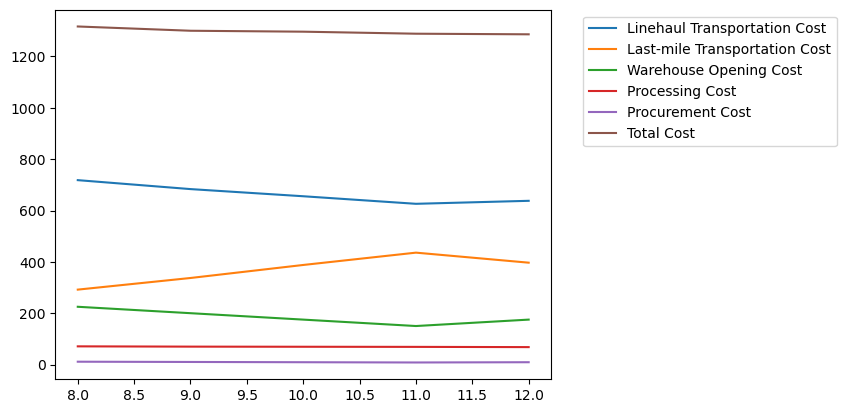

In [74]:
Dura_std_list = range(8, 13)
model.setParam(COPT.Param.Logging, False)

kpi_trans0 = []
kpi_trans1 = []
kpi_opening = []
kpi_process = []
kpi_procure = []
kpi_sum = []

for Dura_std in Dura_std_list:
    Dura_ind = {}
    for key, value in Dura.items():
        if value <= Dura_std * 60:
            Dura_ind[key] = 1
        else:
            Dura_ind[key] = 0

    # Remove the original constraint and add a new one
    model.remove(time_constr)
    time_constr = model.addConstr(
        cp.quicksum(Dura_ind[i, k] * d_cust[i, k, s] for i in dc_list for k in cust_list for s in sku_list) >=
        P_dura * cp.quicksum(D[k, s] for k in cust_list for s in sku_list)
    )

    # Solve the model
    model.setParam("logging", 0)
    model.solve()
    # model.writeLp("Revised.lp")

    # Collect KPI data
    kpi_trans0.append(sum(qty_dc[i, j, s].X * Cost_trans[i, j] for (i, j, s) in dc_flow_idx))
    kpi_trans1.append(sum(d_cust[i, k, s].X * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list))
    kpi_opening.append(sum(wh[i].X * Cost_wh[i] for i in dc_list))
    kpi_process.append(sum(proc[i].X * Proc_cost[i] for i in dc_list))
    kpi_procure.append(sum(procure[i].X * Procure_cost for i in dc_list))
    kpi_sum.append(kpi_trans0[-1] + kpi_trans1[-1] + kpi_opening[-1] + kpi_process[-1] + kpi_procure[-1])

# Plot the results
plt.plot(Dura_std_list, kpi_trans0, label='Linehaul Transportation Cost')
plt.plot(Dura_std_list, kpi_trans1, label='Last-mile Transportation Cost')
plt.plot(Dura_std_list, kpi_opening, label='Warehouse Opening Cost')
plt.plot(Dura_std_list, kpi_process, label='Processing Cost')
plt.plot(Dura_std_list, kpi_procure, label='Procurement Cost')
plt.plot(Dura_std_list, kpi_sum, label='Total Cost')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## 2. 时效满足率（原0.95）
将参数调整为75%到95%之间，观察各项成本的变化情况。

Setting parameter 'Logging' to 1
0.75
[1286.3011314999999]
0.8
[1286.3011314999999, 1286.3011314999999]
0.8500000000000001
[1286.3011314999999, 1286.3011314999999, 1286.931998]
0.9
[1286.3011314999999, 1286.3011314999999, 1286.931998, 1296.7442735]
0.9500000000000001
[1286.3011314999999, 1286.3011314999999, 1286.931998, 1296.7442735, 1316.944237]


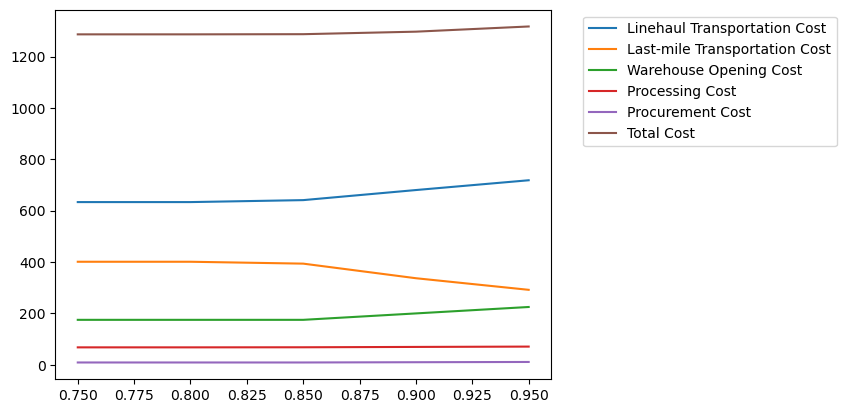

In [78]:
Dura_std = 480
P_dura_list = [i * 0.05 for i in range(15, 20)]
model.setParam(COPT.Param.Logging, True)

kpi_trans0 = []
kpi_trans1 = []
kpi_opening = []
kpi_process = []
kpi_procure = []
kpi_sum = []

# Generate new delivery-time satisfaction data
Dura_ind = {}
for key, value in Dura.items():
    if value <= Dura_std:
        Dura_ind[key] = 1
    else:
        Dura_ind[key] = 0

for P_dura in P_dura_list:
    print(P_dura)

    # Remove the original constraint and add a new one
    model.remove(time_constr)
    time_constr = model.addConstr(
        cp.quicksum(Dura_ind[i, k] * d_cust[i, k, s] for i in dc_list for k in cust_list for s in sku_list) >=
        P_dura * cp.quicksum(D[k, s] for k in cust_list for s in sku_list)
    )

    # Solve the model
    model.setParam("logging", 0)
    model.solve()

    # Collect KPI data
    kpi_trans0.append(sum(qty_dc[i, j, s].X * Cost_trans[i, j] for (i, j, s) in dc_flow_idx))
    kpi_trans1.append(sum(d_cust[i, k, s].X * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list))
    kpi_opening.append(sum(wh[i].X * Cost_wh[i] for i in dc_list))
    kpi_process.append(sum(proc[i].X * Proc_cost[i] for i in dc_list))
    kpi_procure.append(sum(procure[i].X * Procure_cost for i in dc_list))
    kpi_sum.append(kpi_trans0[-1] + kpi_trans1[-1] + kpi_opening[-1] + kpi_process[-1] + kpi_procure[-1])

    print(kpi_sum)

# Plot the results
plt.plot(P_dura_list, kpi_trans0, label='Linehaul Transportation Cost')
plt.plot(P_dura_list, kpi_trans1, label='Last-mile Transportation Cost')
plt.plot(P_dura_list, kpi_opening, label='Warehouse Opening Cost')
plt.plot(P_dura_list, kpi_process, label='Processing Cost')
plt.plot(P_dura_list, kpi_procure, label='Procurement Cost')
plt.plot(P_dura_list, kpi_sum, label='Total Cost')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()